# Monte Carlo Sample Visualization and Analysis

This notebook analyzes and visualizes Monte Carlo samples generated by C++ particle distribution generators. It provides comprehensive statistical analysis, histograms, and 2D density plots for four different sampling methods.

## Load Data into DataFrames

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.constrained_layout.use'] = True

print("Libraries imported successfully.")

Libraries imported successfully.


In [17]:
# Load velocity distribution data
# workspace_root = "./"
workspace_root = "../cpp/"

df_general_velocity = pd.read_csv(workspace_root+'samples_general_velocity.txt', delim_whitespace=True,
                                    names=['vx', 'vy', 'vz'], dtype=np.float64)

# Load position distribution data
df_general_position = pd.read_csv(workspace_root+'samples_general_position.txt', delim_whitespace=True,
                                    names=['x', 'y', 'z'], dtype=np.float64)

print("Data loaded successfully.")
print(f"\nGeneral Velocity Generator:\n  Shape: {df_general_velocity.shape}\n  First 5 rows:\n{df_general_velocity.head()}")
print(f"\nGeneral Position Generator:\n  Shape: {df_general_position.shape}\n  First 5 rows:\n{df_general_position.head()}")

Data loaded successfully.

General Velocity Generator:
  Shape: (1000000, 3)
  First 5 rows:
         vx        vy        vz
0 -0.364494  0.357723 -1.338230
1 -0.261378  0.125368 -0.039236
2  2.313090 -0.423841  1.079670
3 -0.544770  1.804500  0.543581
4  0.642526  0.591596  1.874960

General Position Generator:
  Shape: (1000000, 3)
  First 5 rows:
          x         y             z
0 -1.068320 -0.442634  3.669150e-62
1  0.793197  0.963721  3.669150e-62
2  1.044130  2.033630  3.669150e-62
3 -2.383480  0.425027  3.669150e-62
4 -3.065330  1.570710  3.669150e-62


## Compute Derived Quantities for Velocity Datasets

In [18]:
# Physical parameters
mass = 1.0  # Particle mass (normalized)

# Function to compute derived quantities for velocity data
def compute_velocity_quantities(df):
    df = df.copy()
    df['v_perp'] = np.sqrt(df['vx']**2 + df['vy']**2)  # Perpendicular velocity magnitude
    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)  # Total speed
    df['energy'] = 0.5 * mass * df['speed']**2  # Kinetic energy
    return df

# Compute derived quantities
df_general_velocity = compute_velocity_quantities(df_general_velocity)

print("Derived velocity quantities computed.")

Derived velocity quantities computed.


## Compute Derived Quantities for Position Dataset

In [19]:
# Compute radial coordinate for 2D position data
df_general_position['radius'] = np.sqrt(
    df_general_position['x']**2 + df_general_position['y']**2
)

print("Derived 2D position quantities computed.")
print(f"\nPosition data with radius:\n  Columns: {list(df_general_position.columns)}\n  First 3 rows:\n{df_general_position.head(3)}")

Derived 2D position quantities computed.

Position data with radius:
  Columns: ['x', 'y', 'z', 'radius']
  First 3 rows:
          x         y             z    radius
0 -1.068320 -0.442634  3.669150e-62  1.156388
1  0.793197  0.963721  3.669150e-62  1.248167
2  1.044130  2.033630  3.669150e-62  2.286014


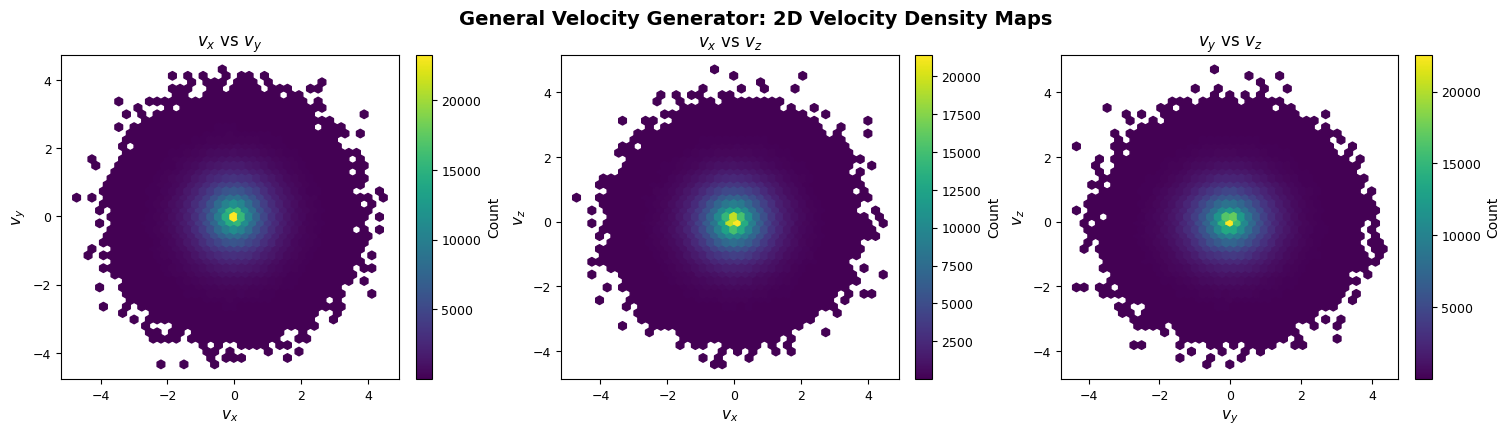

General velocity 2D density maps plotted.


In [20]:
# General velocity generator: 2D density plots for velocity space
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('General Velocity Generator: 2D Velocity Density Maps', fontsize=14, fontweight='bold', y=1.05)

# vx vs vy
hb1 = axes[0].hexbin(df_general_velocity['vx'], df_general_velocity['vy'], gridsize=40, cmap='viridis', mincnt=1)
axes[0].set_xlabel('$v_x$')
axes[0].set_ylabel('$v_y$')
axes[0].set_title('$v_x$ vs $v_y$')
cb1 = plt.colorbar(hb1, ax=axes[0])
cb1.set_label('Count', fontsize=10)

# vx vs vz
hb2 = axes[1].hexbin(df_general_velocity['vx'], df_general_velocity['vz'], gridsize=40, cmap='viridis', mincnt=1)
axes[1].set_xlabel('$v_x$')
axes[1].set_ylabel('$v_z$')
axes[1].set_title('$v_x$ vs $v_z$')
cb2 = plt.colorbar(hb2, ax=axes[1])
cb2.set_label('Count', fontsize=10)

# vy vs vz
hb3 = axes[2].hexbin(df_general_velocity['vy'], df_general_velocity['vz'], gridsize=40, cmap='viridis', mincnt=1)
axes[2].set_xlabel('$v_y$')
axes[2].set_ylabel('$v_z$')
axes[2].set_title('$v_y$ vs $v_z$')
cb3 = plt.colorbar(hb3, ax=axes[2])
cb3.set_label('Count', fontsize=10)

plt.show()

print("General velocity 2D density maps plotted.")

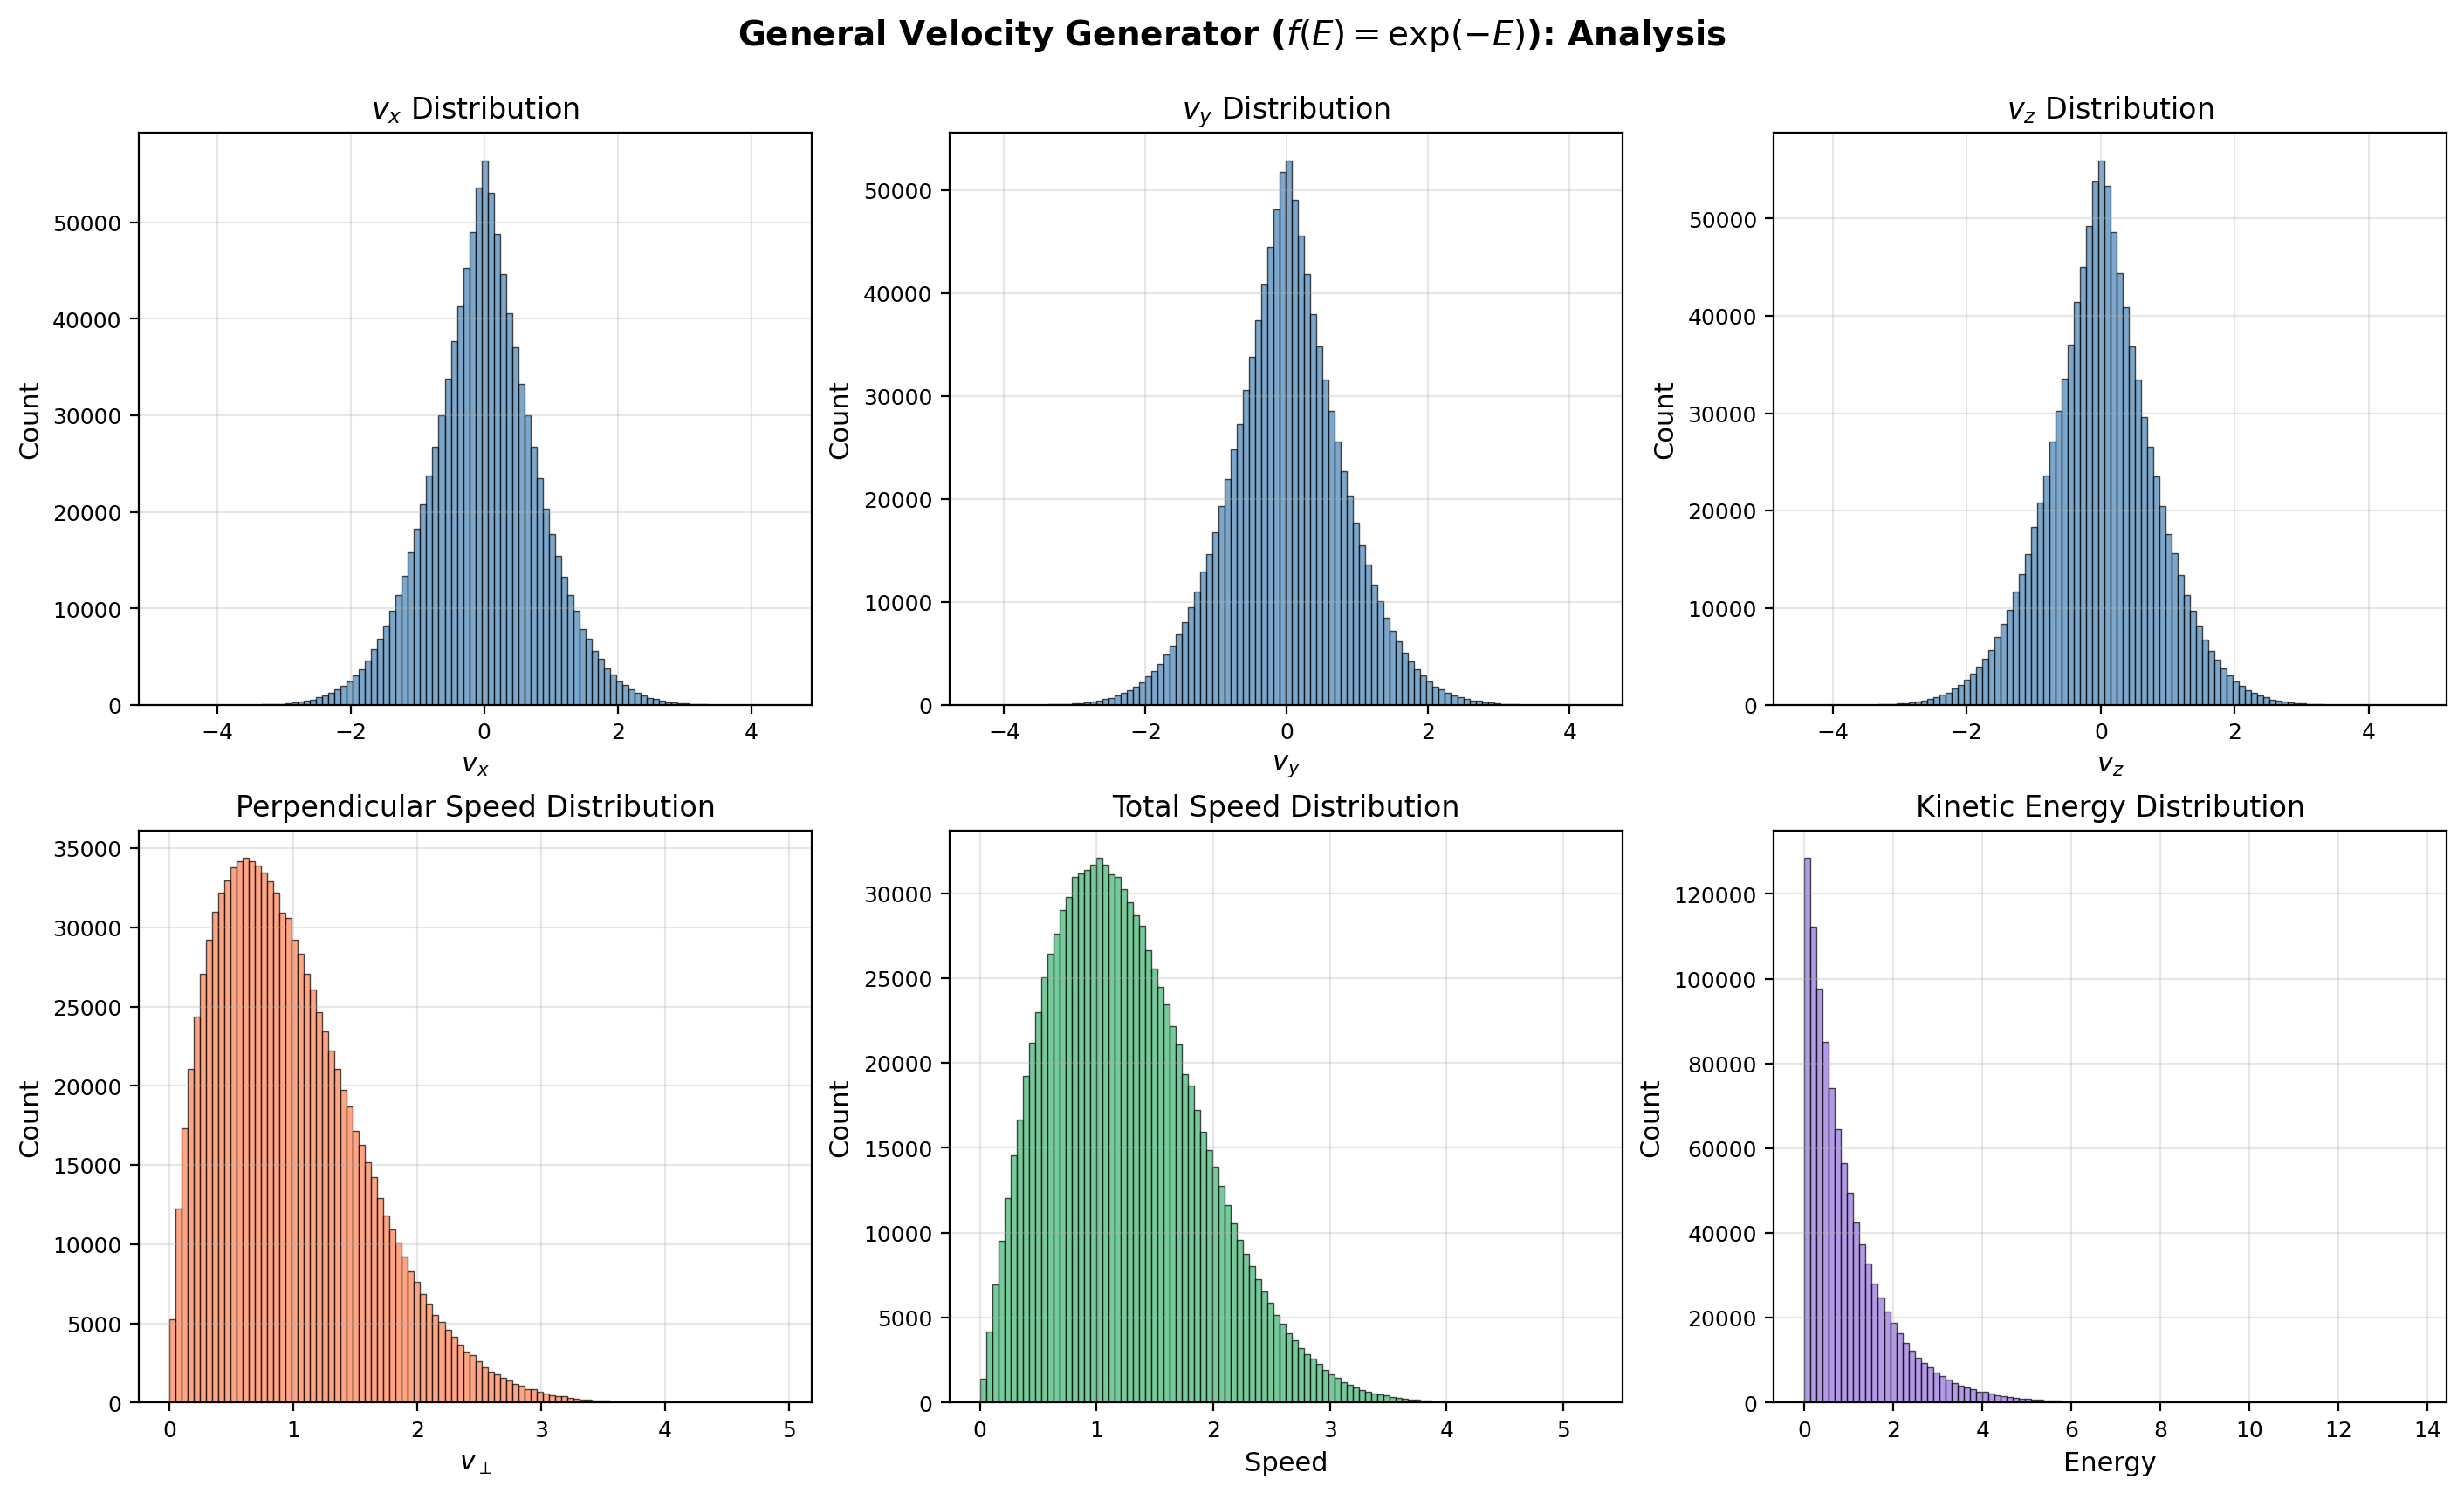

General velocity histograms plotted.


In [21]:
# General velocity generator: Histograms of velocity components and derived quantities
fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=200)
fig.suptitle('General Velocity Generator ($f(E) = \\exp(-E)$): Analysis', fontsize=14, fontweight='bold', y=1.05)

# Velocity components
axes[0, 0].hist(df_general_velocity['vx'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('$v_x$')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('$v_x$ Distribution')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(df_general_velocity['vy'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('$v_y$')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('$v_y$ Distribution')
axes[0, 1].grid(alpha=0.3)

axes[0, 2].hist(df_general_velocity['vz'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 2].set_xlabel('$v_z$')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('$v_z$ Distribution')
axes[0, 2].grid(alpha=0.3)

# Derived quantities
axes[1, 0].hist(df_general_velocity['v_perp'], bins=100, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('$v_{\\perp}$')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Perpendicular Speed Distribution')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df_general_velocity['speed'], bins=100, color='mediumseagreen', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Speed')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Total Speed Distribution')
axes[1, 1].grid(alpha=0.3)

axes[1, 2].hist(df_general_velocity['energy'], bins=100, color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 2].set_xlabel('Energy')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Kinetic Energy Distribution')
axes[1, 2].grid(alpha=0.3)

plt.show()

print("General velocity histograms plotted.")

## General Position Generator Analysis

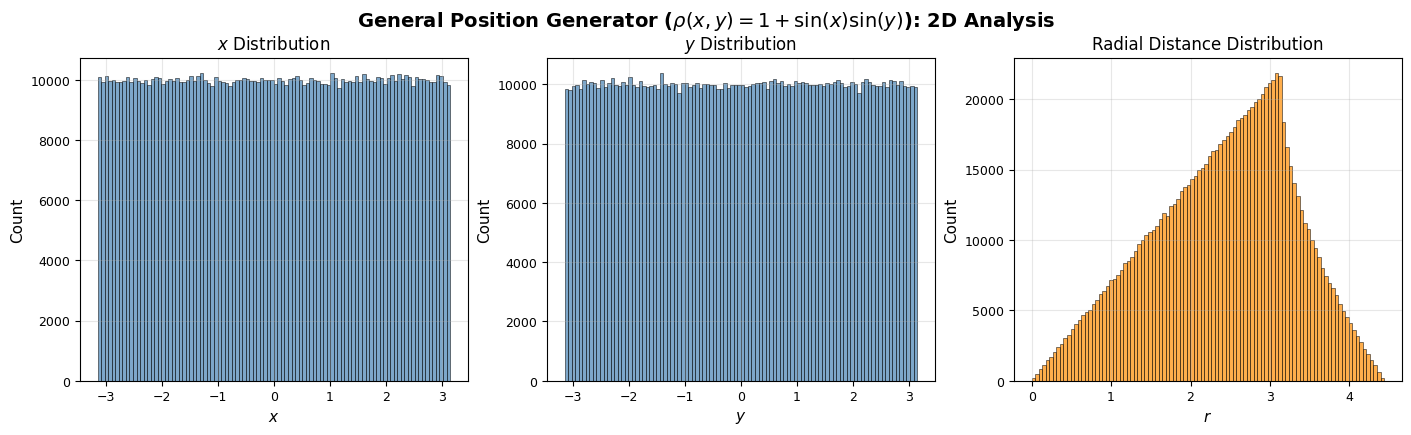

General 2D position histograms plotted.


In [22]:
# General position generator: Histograms of x, y, and radius (2D)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('General Position Generator ($\\rho(x,y) = 1 + \\sin(x)\\sin(y)$): 2D Analysis', fontsize=14, fontweight='bold', y=1.05)

axes[0].hist(df_general_position['x'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('Count')
axes[0].set_title('$x$ Distribution')
axes[0].grid(alpha=0.3)

axes[1].hist(df_general_position['y'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('$y$')
axes[1].set_ylabel('Count')
axes[1].set_title('$y$ Distribution')
axes[1].grid(alpha=0.3)

axes[2].hist(df_general_position['radius'], bins=100, color='darkorange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('$r$')
axes[2].set_ylabel('Count')
axes[2].set_title('Radial Distance Distribution')
axes[2].grid(alpha=0.3)

plt.show()

print("General 2D position histograms plotted.")

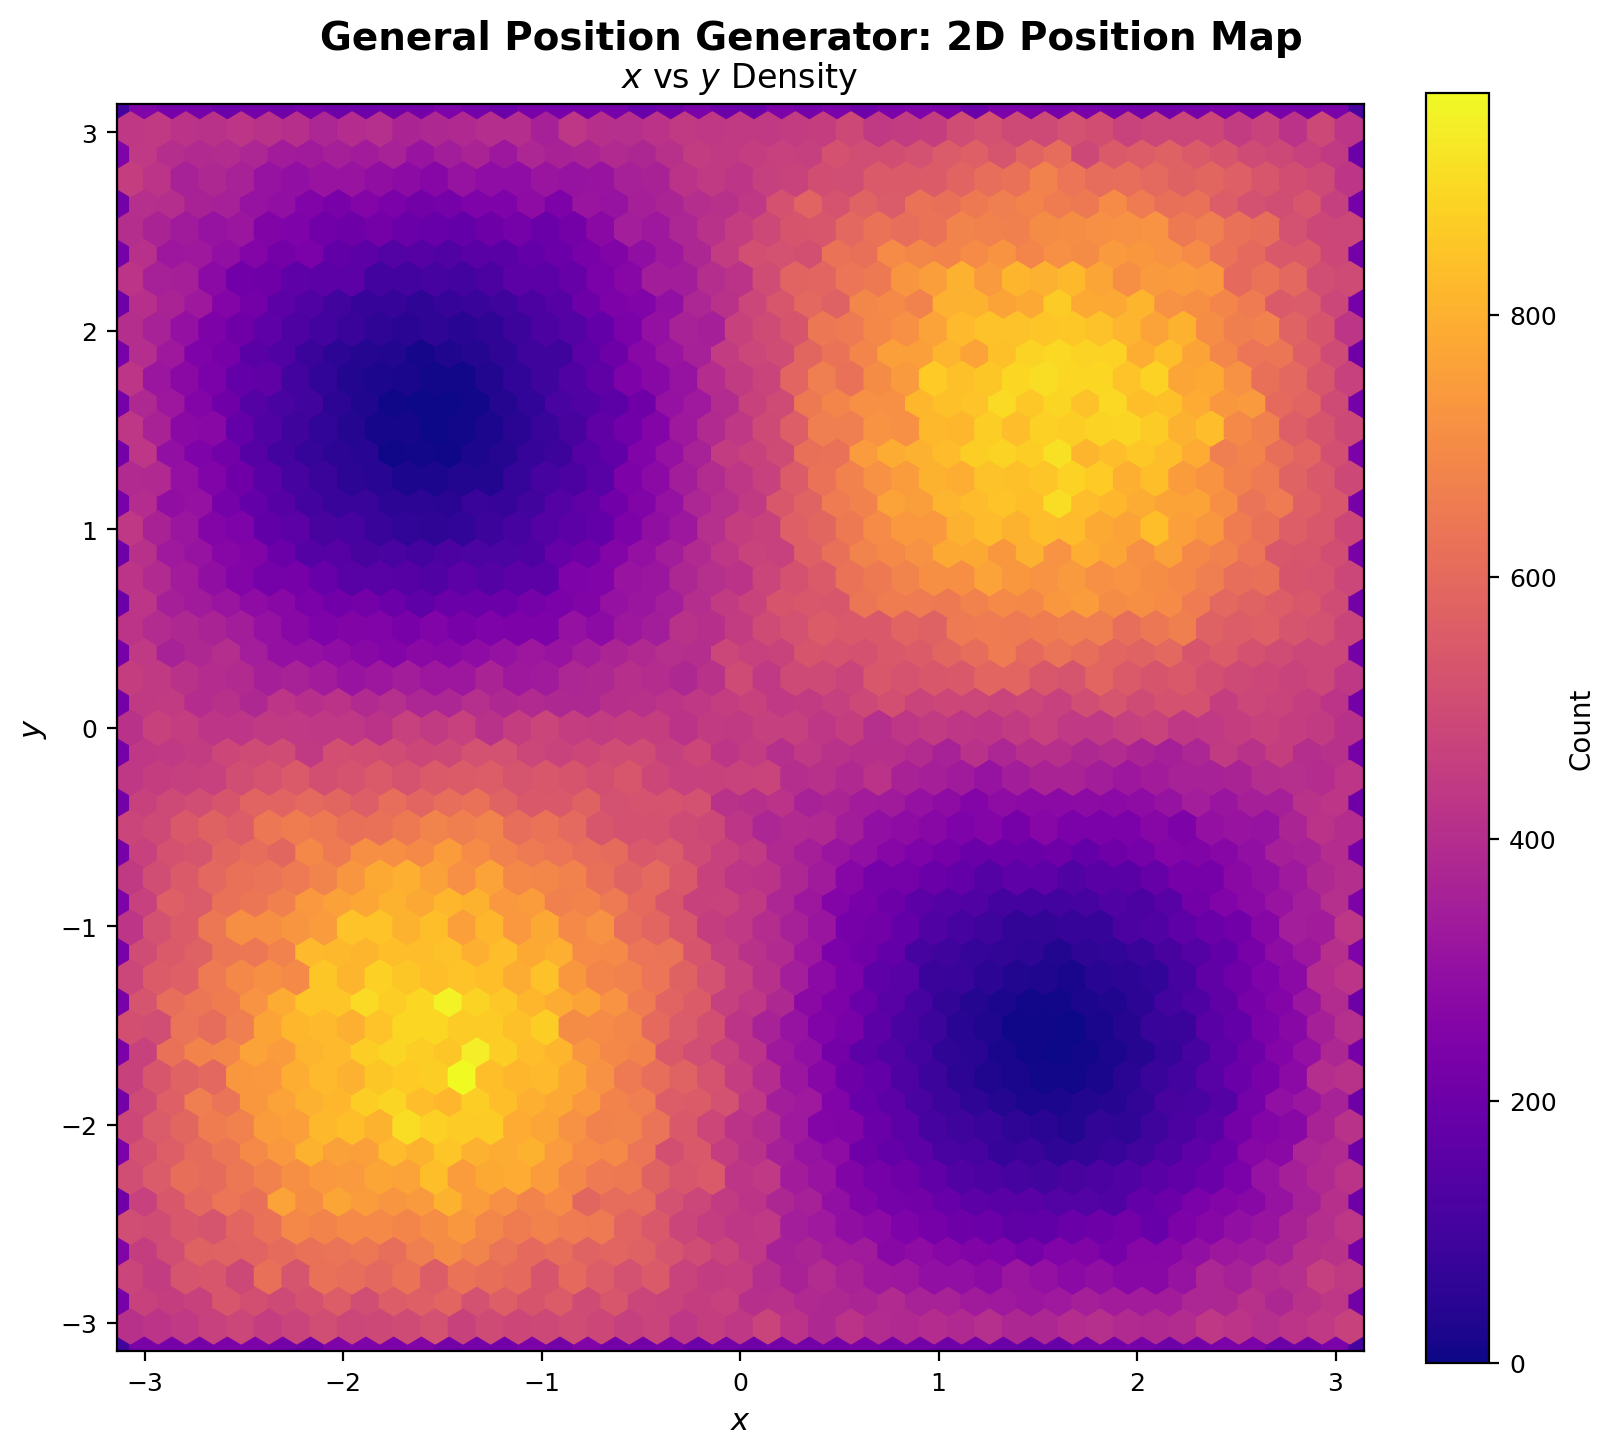

General 2D position map plotted.


In [23]:
# General position generator: 2D position map (hexbin only)
fig, ax = plt.subplots(1, 1, figsize=(8, 7), dpi=200)
fig.suptitle('General Position Generator: 2D Position Map', fontsize=14, fontweight='bold', y=1.02)

hb = ax.hexbin(
    df_general_position['x'],
    df_general_position['y'],
    gridsize=45,
    cmap='plasma',
    mincnt=0
)
from numpy import pi
ax.set_xlim(-pi,pi)
ax.set_ylim(-pi,pi)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('$x$ vs $y$ Density')
ax.set_aspect('equal')

cb0 = plt.colorbar(hb, ax=ax)
cb0.set_label('Count', fontsize=10)

plt.show()

print("General 2D position map plotted.")


### Reference function: $\rho(x,y)=1+\sin(x)\sin(y)$

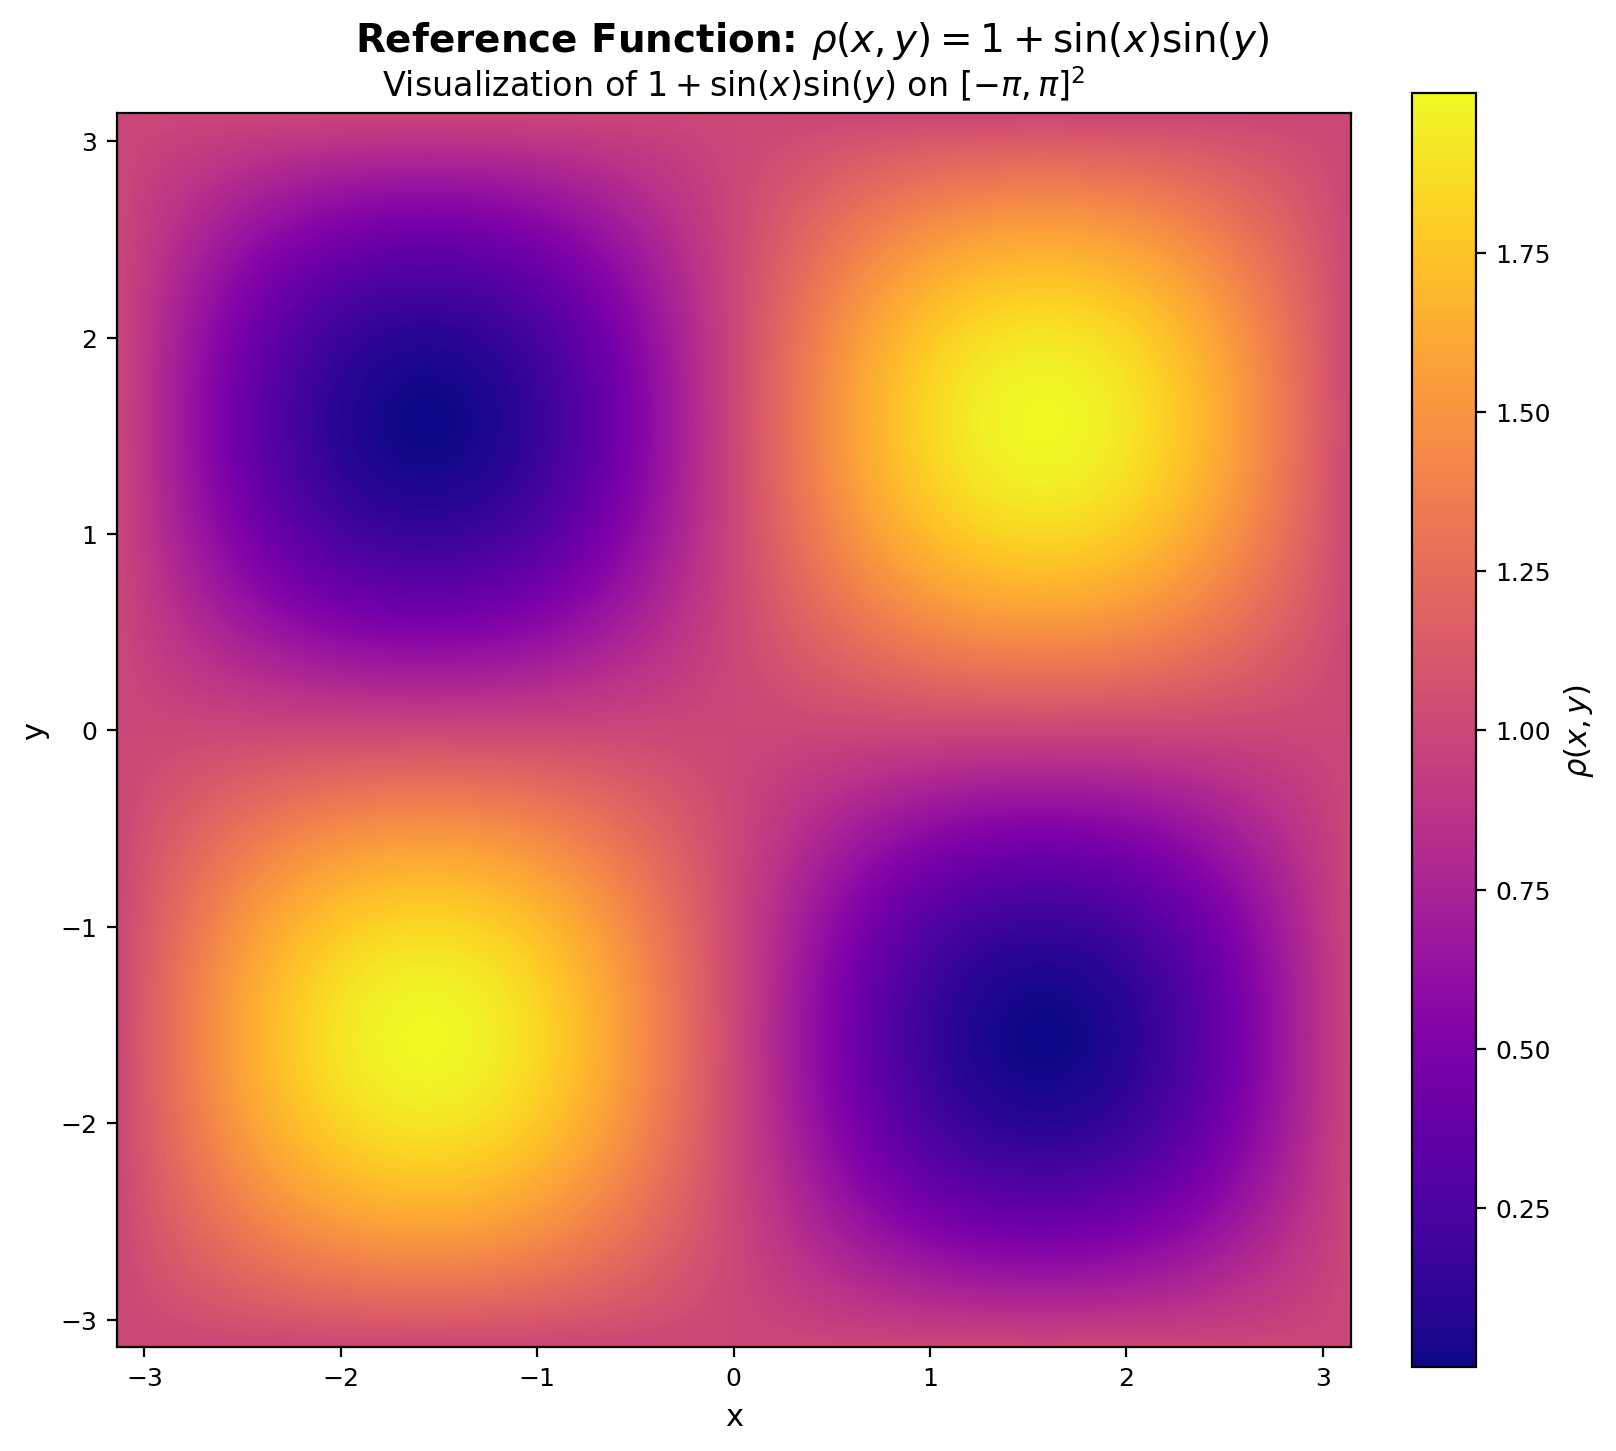

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Grid on [-pi, pi] x [-pi, pi]
n = 400
x = np.linspace(-np.pi, np.pi, n)
y = np.linspace(-np.pi, np.pi, n)
X, Y = np.meshgrid(x, y)

# Function
Z = 1 + np.sin(X) * np.sin(Y)

# Plot
plt.figure(figsize=(8, 7), dpi=200)
plt.suptitle(r'Reference Function: $\rho(x,y)=1+\sin(x)\sin(y)$', fontsize=14, fontweight='bold', y=1.02)
plt.imshow(
    Z,
    extent=(-np.pi, np.pi, -np.pi, np.pi),
    origin="lower",
    aspect="equal",
    cmap="plasma"
)
plt.colorbar(label=r"$\rho(x,y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Visualization of $1+\sin(x)\sin(y)$ on $[-\pi,\pi]^2$")
plt.show()
